In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import Union

In [2]:
METRIC_LIST = ['depth_ratio', 'ops_ratio', 'cx_ratio']

def wide_to_long(df):
    df = pd.melt(
        df,
        id_vars=[col for col in df.columns if col not in METRIC_LIST],
        value_vars=METRIC_LIST,
        var_name='metric',
        value_name='value'
    )
    return df

In [6]:
df = wide_to_long(pd.read_csv('./output/baseline/before_after.csv'))


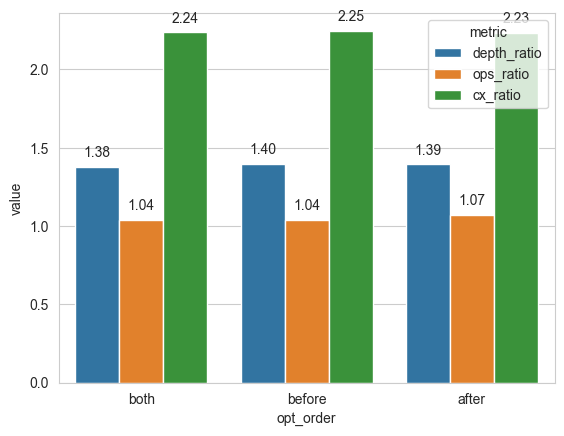

In [10]:
ax = plt.subplot(111)
sns.barplot(df, x='opt_order', y='value', hue='metric', ax=ax, errorbar=None)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=5)